In this notebook, we will build a 3D map of a scene from a small set of images and then localize an image downloaded from the Internet. This demo was contributed by [Philipp Lindenberger](https://github.com/Phil26AT/).

In [2]:
import pycolmap
print(pycolmap.__version__)
print(hasattr(pycolmap, 'estimate_and_refine_absolute_pose'))
print(hasattr(pycolmap, 'absolute_pose_estimation'))
print(hasattr(pycolmap, 'align_model'))



0.6.1
False
True
False


In [3]:
%load_ext autoreload
%autoreload 2
import tqdm, tqdm.notebook

tqdm.tqdm = tqdm.notebook.tqdm  # notebook-friendly progress bars
from pathlib import Path
import numpy as np

from hloc import (
    extract_features,
    match_features,
    reconstruction,
    visualization,
    pairs_from_exhaustive,
)
from hloc.visualization import plot_images, read_image
from hloc.utils import viz_3d

# Setup
Here we define some output paths.

In [4]:
from pathlib import Path
from hloc import extract_features, match_features  # Assuming you have HLoc installed

# Set your Parallax image folder
images = Path(r"C:\Users\hanna.lee\Documents\00_Parallax\002_TestCode\000_ReticleImages")

# Choose where to store the outputs
outputs = Path("outputs/parallax-pipline/")
sfm_pairs = outputs / "pairs-sfm.txt"
loc_pairs = outputs / "pairs-loc.txt"
sfm_dir = outputs / "sfm"
features = outputs / "features.h5"
matches = outputs / "matches.h5"
camera_centers = Path("outputs/cam_centers.txt")

# (Optional) Clear the outputs folder
import shutil
shutil.rmtree(outputs, ignore_errors=True)
outputs.mkdir(parents=True, exist_ok=True)

# Use LightGlue with DISK features
feature_conf = extract_features.confs["disk"]
#feature_conf = extract_features.confs["superpoint_max"]
#matcher_conf = match_features.confs["disk+lightglue"]
matcher_conf = match_features.confs["disk+lightglue"]


In [5]:
"""
import subprocess

def align_model_with_colmap(
    input_path,
    output_path,
    ref_images_path,
    alignment_type="ecef",
    ref_is_gps=False,
    alignment_max_error=3.0
):
    command = [
        "colmap", "model_aligner",
        "--input_path", str(input_path),
        "--output_path", str(output_path),
        "--ref_images_path", str(ref_images_path),
        "--ref_is_gps", "1" if ref_is_gps else "0",
        "--alignment_type", alignment_type,
        "--alignment_max_error", str(alignment_max_error),
    ]
    print("Running COLMAP model_aligner:")
    print(" ".join(command))
    subprocess.run(command, check=True)

    align_model_with_colmap(
    input_path=sfm_dir,
    output_path=outputs / "sfm_geo",
    ref_images_path=camera_centers,
    alignment_type="ecef",    # or "enu" if you'd prefer ENU alignment
    ref_is_gps=False,          # set False if cam_centers.txt is in XYZ Cartesian
    alignment_max_error=3.0
)

"""

'\nimport subprocess\n\ndef align_model_with_colmap(\n    input_path,\n    output_path,\n    ref_images_path,\n    alignment_type="ecef",\n    ref_is_gps=False,\n    alignment_max_error=3.0\n):\n    command = [\n        "colmap", "model_aligner",\n        "--input_path", str(input_path),\n        "--output_path", str(output_path),\n        "--ref_images_path", str(ref_images_path),\n        "--ref_is_gps", "1" if ref_is_gps else "0",\n        "--alignment_type", alignment_type,\n        "--alignment_max_error", str(alignment_max_error),\n    ]\n    print("Running COLMAP model_aligner:")\n    print(" ".join(command))\n    subprocess.run(command, check=True)\n\n    align_model_with_colmap(\n    input_path=sfm_dir,\n    output_path=outputs / "sfm_geo",\n    ref_images_path=camera_centers,\n    alignment_type="ecef",    # or "enu" if you\'d prefer ENU alignment\n    ref_is_gps=False,          # set False if cam_centers.txt is in XYZ Cartesian\n    alignment_max_error=3.0\n)\n\n'

# 3D mapping
First we list the images used for mapping. These are all day-time shots of Sacre Coeur.

4 mapping images


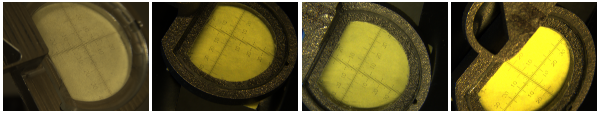

In [6]:
references = [p.relative_to(images).as_posix() for p in (images / "mapping/").iterdir()]
print(len(references), "mapping images")
plot_images([read_image(images / r) for r in references], dpi=25)

Then we extract features and match them across image pairs. Since we deal with few images, we simply match all pairs exhaustively. For larger scenes, we would use image retrieval, as demonstrated in the other notebooks.

In [7]:
extract_features.main(
    feature_conf, images, image_list=references, feature_path=features
)
pairs_from_exhaustive.main(sfm_pairs, image_list=references)
match_features.main(matcher_conf, sfm_pairs, features=features, matches=matches);

[2025/04/08 11:58:38 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 5000, 'name': 'disk'},
 'output': 'feats-disk',
 'preprocessing': {'grayscale': False, 'resize_max': 1600}}
c:\Users\hanna.lee\Documents\00_Parallax\000_Project\hloc\Hierarchical-Localization\venv\lib\site-packages\kornia\feature\lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


  0%|          | 0/4 [00:00<?, ?it/s]

[2025/04/08 11:58:54 hloc INFO] Finished exporting features.
[2025/04/08 11:58:54 hloc INFO] Found 6 pairs.
[2025/04/08 11:58:54 hloc INFO] Matching local features with configuration:
{'model': {'features': 'disk', 'name': 'lightglue'},
 'output': 'matches-disk-lightglue'}
c:\Users\hanna.lee\Documents\00_Parallax\000_Project\hloc\Hierarchical-Localization\venv\lib\site-packages\lightglue\lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


  0%|          | 0/6 [00:00<?, ?it/s]

[2025/04/08 11:59:29 hloc INFO] Finished exporting matches.


The we run incremental Structure-From-Motion and display the reconstructed 3D model.

In [8]:
# Reconstruction with known camera parameters 
#opts = dict(camera_model='SIMPLE_RADIAL', camera_params=','.join(map(str, (f, cx, cy, k))))
#model = reconstruction.main(..., image_options=opts)
#By default, hloc refines the camera parameters during the reconstruction process. To prevent this, add:
#reconstruction.main(..., mapper_options=dict(ba_refine_focal_length=False, ba_refine_extra_params=False))
# The reconstruction process can be controlled with the following options:

fx, fy, cx, cy = 15400.0, 15400.0, 2000.0, 1500.0
opts = dict(
    camera_model='PINHOLE',
    camera_params=','.join(map(str, (fx, fy, cx, cy)))
)

mapper_options=dict(
    ba_refine_focal_length=False,
    ba_refine_extra_params=False
)

# ------------------------------------------------------------------
model = reconstruction.main(
    sfm_dir, images, sfm_pairs, features, matches, 
    image_list=references,
    image_options=opts,
    mapper_options = mapper_options
)
fig = viz_3d.init_figure()
viz_3d.plot_reconstruction(
    fig, model, color="rgba(255,0,0,0.5)", name="mapping", points_rgb=True
)
fig.show()

[2025/04/08 11:59:30 hloc INFO] Creating an empty database...
[2025/04/08 11:59:30 hloc INFO] Importing images into the database...
[2025/04/08 11:59:30 hloc INFO] Importing features into the database...


  0%|          | 0/4 [00:00<?, ?it/s]

[2025/04/08 11:59:30 hloc INFO] Importing matches into the database...


  0%|          | 0/6 [00:00<?, ?it/s]

[2025/04/08 11:59:30 hloc INFO] Performing geometric verification of the matches...
[2025/04/08 11:59:31 hloc INFO] Running 3D reconstruction...
[2025/04/08 11:59:32 hloc INFO] Reconstructed 1 model(s).
[2025/04/08 11:59:32 hloc INFO] Largest model is #0 with 4 images.
[2025/04/08 11:59:32 hloc INFO] Reconstruction statistics:
Reconstruction:
	num_reg_images = 4
	num_cameras = 4
	num_points3D = 384
	num_observations = 925
	mean_track_length = 2.40885
	mean_observations_per_image = 231.25
	mean_reprojection_error = 1.29583
	num_input_images = 4


We also visualize which keypoints were triangulated into the 3D model.

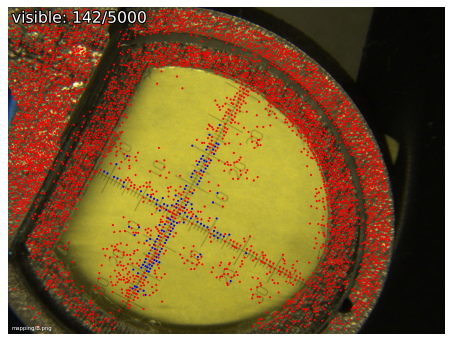

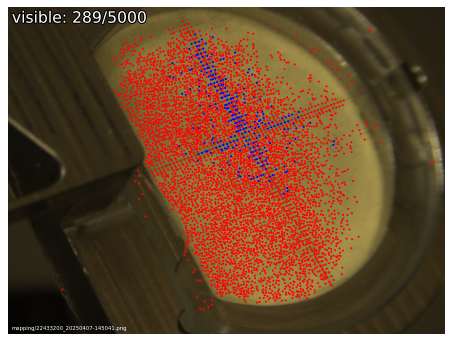

In [ ]:
visualization.visualize_sfm_2d(model, images, color_by="visibility", n=5)

# Localization
Now that we have a 3D map of the scene, we can localize any image. To demonstrate this, we download [a night-time image from Wikimedia](https://commons.wikimedia.org/wiki/File:Paris_-_Basilique_du_Sacr%C3%A9_Coeur,_Montmartre_-_panoramio.jpg).

In [ ]:
# List all files in the queries folder
images = Path(r"C:\Users\hanna.lee\Documents\00_Parallax\002_TestCode\000_ReticleImages")
query_folder = images / "queries"
for file in query_folder.glob("*"):
    print(file.name)


Microscope_1_20250403-094514.png
Microscope_3_20250403-094514.png


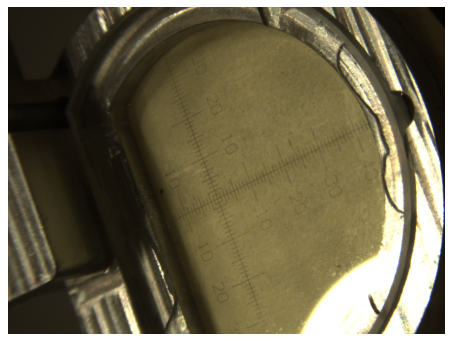

In [ ]:
from hloc.utils.viz import plot_images
from pathlib import Path

# Define your base image folder
images = Path(r"C:\Users\hanna.lee\Documents\00_Parallax\002_TestCode\000_ReticleImages")

# Define your query image path (relative to `images`)
query = "queries/Microscope_3_20250403-094514.png"
#query = "queries/Microscope_1_20250403-094514.png"


# Plot it
plot_images([read_image(images / query)], dpi=75)


Again, we extract features for the query and match them exhaustively.

In [ ]:
extract_features.main(
    feature_conf, images, image_list=[query], feature_path=features, overwrite=True
)
pairs_from_exhaustive.main(loc_pairs, image_list=[query], ref_list=references)
match_features.main(
    matcher_conf, loc_pairs, features=features, matches=matches, overwrite=True
);

[2025/04/07 15:52:33 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 5000, 'name': 'disk'},
 'output': 'feats-disk',
 'preprocessing': {'grayscale': False, 'resize_max': 1600}}


  0%|          | 0/1 [00:00<?, ?it/s]

[2025/04/07 15:52:47 hloc INFO] Finished exporting features.
[2025/04/07 15:52:47 hloc INFO] Found 4 pairs.
[2025/04/07 15:52:47 hloc INFO] Matching local features with configuration:
{'model': {'features': 'disk', 'name': 'lightglue'},
 'output': 'matches-disk-lightglue'}


  0%|          | 0/4 [00:00<?, ?it/s]

[2025/04/07 15:53:02 hloc INFO] Finished exporting matches.


We read the EXIF data of the query to infer a rough initial estimate of camera parameters like the focal length. Then we estimate the absolute camera pose using PnP+RANSAC and refine the camera parameters.

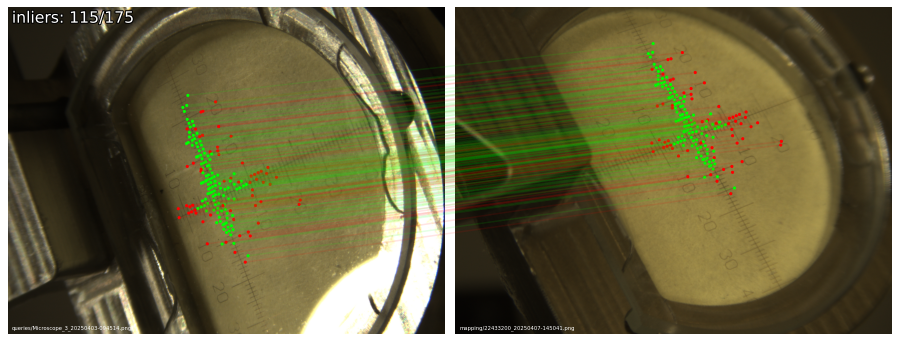

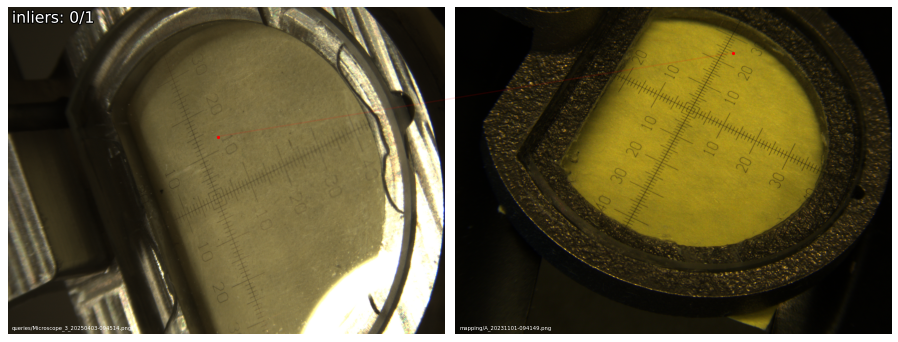

In [ ]:
import pycolmap
from hloc.localize_sfm import QueryLocalizer, pose_from_cluster

camera = pycolmap.infer_camera_from_image(images / query)
ref_ids = [model.find_image_with_name(r).image_id for r in references]
conf = {
    "estimation": {"ransac": {"max_error": 12}},
    "refinement": {"refine_focal_length": True, "refine_extra_params": True},
}
localizer = QueryLocalizer(model, conf)
ret, log = pose_from_cluster(localizer, query, camera, ref_ids, features, matches)

#print(f'found {ret["num_inliers"]}/{len(ret["inliers"])} inlier correspondences.')
visualization.visualize_loc_from_log(images, query, log, model)

We visualize the correspondences between the query images a few mapping images. We can also visualize the estimated camera pose in the 3D map.

In [ ]:
pose = pycolmap.Image(cam_from_world=ret["cam_from_world"])
viz_3d.plot_camera_colmap(
    fig, pose, camera, color="rgba(0,255,0,0.5)", name=query, fill=True
)
# visualize 2D-3D correspodences
inl_3d = np.array(
    [model.points3D[pid].xyz for pid in np.array(log["points3D_ids"])[ret["inliers"]]]
)
viz_3d.plot_points(fig, inl_3d, color="lime", ps=1, name=query)
fig.show()

In [ ]:
model.write(outputs)

In [ ]:
model

Reconstruction(num_reg_images=4, num_cameras=4, num_points3D=384, num_observations=925)

In [ ]:
for pt in model.points3D.values():
    print(pt.xyz, pt.color, pt.error)


[1.09317055 3.76437718 8.57326419] [227 181  63] 0.9094434934005724
[1.31287921 3.6991604  8.63290775] [232 223  60] 1.1927043063006693
[1.12436337 3.37503146 8.82209824] [172 146  24] 1.613451232050587
[1.04310211 3.80212742 8.54998933] [228 195  48] 0.8053719598969765
[1.36612441 3.38950339 8.82750465] [141 128  12] 1.1456172160175562
[1.30083864 3.39740595 8.81724409] [163 127  22] 2.046336199596644
[1.27021331 3.40395042 8.81841687] [159 145  21] 0.6461988028360373
[0.75577497 3.83148706 8.49265569] [232 232  45] 0.35474996523088914
[1.05551468 3.40263307 8.81601165] [163 138  30] 0.539614467889419
[1.06940476 3.77134982 8.5648911 ] [255 230  29] 0.13146094473623765
[1.32696844 3.41136931 8.8195868 ] [141 130  19] 1.550947640883654
[0.81881199 3.86277503 8.48789061] [255 242  20] 1.7220628123423516
[1.34273169 3.41830058 8.80455252] [142 137  16] 1.2347320482473996
[1.06075861 3.41494588 8.79965346] [169 146  19] 2.4487731761702998
[1.36767056 3.42452307 8.80581405] [151 122  29] 1

In [ ]:
from pathlib import Path

def write_points3D_to_ply(model, path):
    with open(path, 'w') as f:
        pts = list(model.points3D.values())
        f.write("ply\nformat ascii 1.0\nelement vertex {}\n".format(len(pts)))
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property uchar red\nproperty uchar green\nproperty uchar blue\nend_header\n")
        for pt in pts:
            x, y, z = pt.xyz
            r, g, b = pt.color
            f.write(f"{x:.6f} {y:.6f} {z:.6f} {r} {g} {b}\n")

# Usage
output_ply_path = Path("outputs/parallax-demo/sfm/points3D.ply")
write_points3D_to_ply(model, output_ply_path)
print(f"✅ Exported to {output_ply_path.resolve()}")


AttributeError: 'WindowsPath' object has no attribute 'points3D'

In [ ]:
from pathlib import Path
import pycolmap

def write_points3D_to_ply(model, path):
    with open(path, 'w') as f:
        pts = list(model.points3D.values())
        f.write("ply\nformat ascii 1.0\nelement vertex {}\n".format(len(pts)))
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property uchar red\nproperty uchar green\nproperty uchar blue\nend_header\n")
        for pt in pts:
            x, y, z = pt.xyz
            r, g, b = pt.color
            f.write(f"{x:.6f} {y:.6f} {z:.6f} {r} {g} {b}\n")

# Load the aligned model using pycolmap
model_path_ = Path("outputs/parallax-demo-aligned")
model_aligned = pycolmap.Reconstruction(model_path_)

# Export to PLY
output_ply_path_ = model_path_ / "points3D.ply"
write_points3D_to_ply(model_aligned, output_ply_path_)
print(f"✅ Exported to {output_ply_path_.resolve()}")


✅ Exported to C:\Users\hanna.lee\Documents\00_Parallax\000_Project\hloc\Hierarchical-Localization\outputs\parallax-demo-aligned\points3D.ply


In [ ]:
for image in model_aligned.images.values():
    pose = pycolmap.Image(cam_from_world=image.cam_from_world)
    cam = model.cameras[image.camera_id]
    viz_3d.plot_camera_colmap(fig, pose, cam, color="rgba(0,0,255,0.3)", name=image.name)
